# Combined Model: Behavioural Features + NLP Embeddings

This notebook combines:

- **Behavioural features** from the COSOWELL survey
- **NLP embeddings** from COSOWELL narratives using `sentence-transformers`
- The combined feature set is used to predict **loneliness level** (low / moderate / high)

## 1. Setting Up

### 1.1 Import Dependencies

In [1]:
import os
import joblib
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support, make_scorer, f1_score
)

### 1.2 Load Data

The COSOWELL dataset zip is at the project root (`../../cosowell_data.zip`). We read CSVs directly from the zip in memory (no extraction needed):
- `cosowell_survey_v2.csv` — behavioural survey features
- `cosowell_corpus_v2.csv` — narrative texts (token-level)

In [2]:
zip_path = os.path.join('..', '..', 'cosowell_data.zip')

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('cosowell-data/cosowell_survey_v2.csv') as f:
        survey_df = pd.read_csv(f)

print(f"Survey shape: {survey_df.shape}")
survey_df.head()

Survey shape: (2621, 65)


,id,age,phase,gender,retired,education,education2,age_education,years_education,read_ability,...,reg3_num,reg5_num,reg7_num,reg8_num,reg10_num,expressive_suppression,reg2_num,reg4_num,reg6_num,reg9_num
0,954f38426899f477b39f0ceab6611c59,62,pre_cov,male,yes,"some college, no degree",college,21.0,15.0,excellent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,e42ca2d461291c17990883401d811f57,64,pre_cov,male,yes,associate's degree,college,24.0,18.0,excellent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,810c90536c9e0200fe8991b5276bb1f6,70,pre_cov,female,yes,master's degree,graduate,40.0,20.0,excellent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2d00d5f885b807e93814e8ee26aa1ba4,62,pre_cov,female,no,bachelor's degree,bachelor,21.0,16.0,very_good,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,642fd812a33d8e78b257c8b9a0d9f632,61,pre_cov,male,no,bachelor's degree,bachelor,22.0,16.0,excellent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('cosowell-data/cosowell_corpus_v2.csv') as f:
        corpus_df = pd.read_csv(f, usecols=['id', 'narrative'])

print(f"Corpus shape: {corpus_df.shape}")
corpus_df.head()

Corpus shape: (1966579, 2)


,id,narrative
0,d2f23157fcc095159a1996be02629752,My wife was finishing up washing dishes yester...
1,d2f23157fcc095159a1996be02629752,My wife was finishing up washing dishes yester...
2,d2f23157fcc095159a1996be02629752,My wife was finishing up washing dishes yester...
3,d2f23157fcc095159a1996be02629752,My wife was finishing up washing dishes yester...
4,d2f23157fcc095159a1996be02629752,My wife was finishing up washing dishes yester...


## 2. Data Preparation

### 2.1 Preprocess Behavioural Features

- Drop leakage columns used to compute loneliness score (companion, leftout, isolated)
- Drop session 7/8-only subjective columns (flourish, regulation scores)
- Drop redundant / non-generalizable features (education2, age_education, confide_*, phase, country, state_province)
- Create loneliness level bins: low (3-4), moderate (5-6), high (7-9)

In [4]:
# Deduplicate survey by id (keep first response)
print(f"=== Before dedup ===")
print(f"Shape: {survey_df.shape}")
print(f"Unique IDs: {survey_df['id'].nunique()}")

survey_df = survey_df.drop_duplicates(subset=['id'], keep='first')

print(f"\n=== After dedup ===")
print(f"Shape: {survey_df.shape}")

# Drop columns that leak the target or are mostly NA (session 7/8 only)
drop_cols_leakage = [
    "test_session",
    "companion", "leftout", "isolated", # directly used to compute loneliness score
    "well_being_score",                 # derived target-adjacent score
]

drop_cols_session_78 = [
    "flourish1_num", "flourish2_num", "flourish3_num", "flourish4_num",
    "flourish5_num", "flourish6_num", "flourish7_num", "flourish8_num",
    "reg1_num", "reg2_num", "reg3_num", "reg4_num", "reg5_num",
    "reg6_num", "reg7_num", "reg8_num", "reg9_num", "reg10_num",
    "expressive_suppression",
    "cognitive_reappraisal",
]

# Drop redundant / non-generalizable features
drop_cols_redundant = [
    "education2",        # coarser grouping of 'education' (redundant)
    "age_education",     # derivable from age + years_education (redundant)
    "confide_spouse",    # overlaps with divulge_spouse / rely_spouse
    "confide_family",    # overlaps with divulge_family / rely_family
    "confide_friend",    # overlaps with divulge_friend / rely_friend
    "confide_colleague", # no corresponding divulge/rely pair (low signal)
    "phase",             # dataset collection artifact (pre_cov vs cov), not a patient feature
    "country",           # high-cardinality geographic (creates sparse dummies, unlikely to generalise)
    "state_province",    # same as country
]

drop_cols = drop_cols_leakage + drop_cols_session_78 + drop_cols_redundant
survey_clean = survey_df.drop(columns=drop_cols)
print(f"\nDropped {len(drop_cols)} columns (leakage + session-7/8 + redundant) → Shape: {survey_clean.shape}")

# Create loneliness level target
def loneliness_category(x):
    if x in [3, 4]:
        return "low"
    elif x in [5, 6]:
        return "moderate"
    elif x in [7, 8, 9]:
        return "high"

survey_clean["loneliness_level"] = survey_clean["loneliness"].apply(loneliness_category)
survey_clean = survey_clean.dropna(subset=["loneliness_level"])
print(f"Dropped rows without valid loneliness_level → Shape: {survey_clean.shape}")

# Report and drop rows with NaNs
print(f"\n=== Before NaN removal ===")
print(f"Shape: {survey_clean.shape}")
nan_counts = survey_clean.isna().sum()
print(f"Total NaNs: {nan_counts.sum()}")
print(f"Rows with any NaN: {survey_clean.isna().any(axis=1).sum()}")
print(f"NaNs per column (non-zero only):")
print(nan_counts[nan_counts > 0].to_string() if nan_counts.sum() > 0 else "  None")

survey_clean = survey_clean.dropna()

print(f"\n=== After NaN removal ===")
print(f"Shape: {survey_clean.shape}")
print(f"Total NaNs: {survey_clean.isna().sum().sum()}")
print(f"\nClass distribution:\n{survey_clean['loneliness_level'].value_counts()}")

survey_clean.head()

=== Before dedup ===
Shape: (2621, 65)
Unique IDs: 2054

=== After dedup ===
Shape: (2054, 65)

Dropped 34 columns (leakage + session-7/8 + redundant) → Shape: (2054, 31)
Dropped rows without valid loneliness_level → Shape: (2041, 32)

=== Before NaN removal ===
Shape: (2041, 32)
Total NaNs: 264
Rows with any NaN: 196
NaNs per column (non-zero only):
education                 12
years_education            2
read_ability               4
write_ability              9
speak_habit               65
read_print_habit           2
read_web_habit            22
broadcast_habit           34
num_friends                2
social_meet_freq           2
professional_meet_freq     3
volunteer_meet_freq        3
num_household             11
talk_social_network        1
divulge_family             6
rely_family                6
divulge_friend             8
rely_friend                7
divulge_spouse            18
rely_spouse               21
health                     3
learning_disability        4
employed 

,id,age,gender,retired,education,years_education,read_ability,write_ability,speak_habit,read_print_habit,...,divulge_spouse,rely_spouse,health,learning_disability,employed,volunteer,living_arrangements,residency,loneliness,loneliness_level
0,954f38426899f477b39f0ceab6611c59,62,male,yes,"some college, no degree",15.0,excellent,very_good,1.0,1.0,...,often,often,fair,no,no,no,spouse_partner,private_apartment_or_home,5.0,moderate
1,e42ca2d461291c17990883401d811f57,64,male,yes,associate's degree,18.0,excellent,excellent,1.0,2.0,...,never,never,good,no,no,no,alone,residential_care_or_home,3.0,low
2,810c90536c9e0200fe8991b5276bb1f6,70,female,yes,master's degree,20.0,excellent,excellent,4.0,1.0,...,often,often,good,no,no,no,spouse_partner,private_apartment_or_home,3.0,low
3,2d00d5f885b807e93814e8ee26aa1ba4,62,female,no,bachelor's degree,16.0,very_good,excellent,4.0,2.0,...,often,some_of_the_time,good,no,full,no,else,private_apartment_or_home,3.0,low
5,30951e5de3b0a3d893fc380997fe5da7,58,male,no,master's degree,22.0,excellent,excellent,1.0,1.0,...,often,often,good,no,full,no,spouse_partner,private_apartment_or_home,3.0,low


### 2.2 Preprocess NLP Features

In [5]:
# The corpus is token-level (~2M rows). We only need unique narratives per user.
print(f"=== Before dedup ===")
print(f"Shape: {corpus_df.shape}")
print(f"Unique IDs: {corpus_df['id'].nunique()}")

corpus_df = corpus_df.drop_duplicates(subset=['id'], keep='first')

print(f"\n=== After dedup ===")
print(f"Shape: {corpus_df.shape}")

# Report and drop rows with NaNs
print(f"\n=== Before NaN removal ===")
nan_counts = corpus_df.isna().sum()
print(f"Total NaNs: {nan_counts.sum()}")
print(f"Rows with any NaN: {corpus_df.isna().any(axis=1).sum()}")
print(f"NaNs per column (non-zero only):")
print(nan_counts[nan_counts > 0].to_string() if nan_counts.sum() > 0 else "  None")

corpus_df = corpus_df.dropna()

print(f"\n=== After NaN removal ===")
print(f"Shape: {corpus_df.shape}")
print(f"Total NaNs: {corpus_df.isna().sum().sum()}")

corpus_df.head()

=== Before dedup ===
Shape: (1966579, 2)
Unique IDs: 1506

=== After dedup ===
Shape: (1506, 2)

=== Before NaN removal ===
Total NaNs: 0
Rows with any NaN: 0
NaNs per column (non-zero only):
  None

=== After NaN removal ===
Shape: (1506, 2)
Total NaNs: 0


,id,narrative
0,d2f23157fcc095159a1996be02629752,My wife was finishing up washing dishes yester...
192,b5698c413b6b9f083a363742c4058344,"Yesterday, after my kids came home from school..."
408,e63019861f7ebff81f165d8ba7c1a1e6,"Yesterday was a mess, but our family survived,..."
643,9aa5d91a7a14bb1b078ff1cf3f8c6d2e,I just woke up from a nightmare. I dreamed I w...
802,5511e53030cce9fce5c982d78f7221f1,We always seemed to be a family of accidents a...


### 2.3 Merge Survey + Narratives

In [6]:
# Inner join on `id`
# Only keep users who have both behavioural data and a narrative

merged_df = pd.merge(survey_clean, corpus_df, on='id', how='inner')
print(f"Merged shape: {merged_df.shape}")
print(f"\nClass distribution after merge:\n{merged_df['loneliness_level'].value_counts()}")

Merged shape: (1237, 33)

Class distribution after merge:
loneliness_level
low         758
moderate    295
high        184
Name: count, dtype: int64


### 2.4 Generate `sentence-transformer` Embeddings

In [7]:
model_name = 'all-MiniLM-L6-v2'
st_model = SentenceTransformer(model_name)

narratives = merged_df['narrative'].tolist()
print(f"Encoding {len(narratives)} narratives with {model_name}...")
embeddings = st_model.encode(narratives, show_progress_bar=True, batch_size=64)

# Create a DataFrame with embedding columns
embedding_cols = [f'emb_{i}' for i in range(embeddings.shape[1])]
embeddings_df = pd.DataFrame(embeddings, columns=embedding_cols, index=merged_df.index)

print(f"Embedding shape: {embeddings_df.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1176.48it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 1237 narratives with all-MiniLM-L6-v2...


Batches: 100%|██████████| 20/20 [00:02<00:00,  9.96it/s]

Embedding shape: (1237, 384)


### 2.5 Build Combined Feature Matrix

In [8]:
# Concatenate one-hot encoded behavioural features with sentence embeddings.
# Prepare behavioural features (drop id, narrative, loneliness, loneliness_level)
behavioural_df = merged_df.drop(columns=['id', 'narrative', 'loneliness', 'loneliness_level'])
behavioural_df = pd.get_dummies(behavioural_df, drop_first=True)

print(f"Behavioural features: {behavioural_df.shape[1]}")
print(f"NLP embedding features: {embeddings_df.shape[1]}")

# Combine
X_combined = pd.concat([behavioural_df.reset_index(drop=True), embeddings_df.reset_index(drop=True)], axis=1)
print(f"Combined feature matrix: {X_combined.shape}")

# Target
y_map = {"low": 1, "moderate": 2, "high": 3}
y = merged_df["loneliness_level"].map(y_map).reset_index(drop=True)
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

Behavioural features: 81
NLP embedding features: 384
Combined feature matrix: (1237, 465)

Target distribution:
loneliness_level
1    758
2    295
3    184
Name: count, dtype: int64


### 2.6 Train/Validation/Test Split + Scaling

In [9]:
# 80/20 train-test, then 80/20 train-val within train
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# Scale features — fit on training data only
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
X_train_val = pd.DataFrame(scaler.transform(X_train_val), columns=X_train_val.columns, index=X_train_val.index)

print(f"\nScaling applied (fit on train, transform all splits)")

Train: 791, Validation: 198, Test: 248

Scaling applied (fit on train, transform all splits)


## 3. Modeling

### 3.1 Baseline + Hyperparameter Tuning

In [ ]:
# SMOTE is applied inside each CV fold via imblearn Pipeline to prevent data leakage
macro_f1_scorer = make_scorer(f1_score, average='macro')

# Baseline: RF with default params
baseline_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced')),
])

cv_scores = cross_val_score(baseline_pipeline, X_train, y_train, cv=3, scoring=macro_f1_scorer)
baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_val)
prec, rec, f1, sup = precision_recall_fscore_support(y_val, y_pred, average='macro')

print(f"=== Baseline RandomForest ===")
print(f"CV Macro F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Validation Macro F1: {f1:.4f}")
print(classification_report(y_val, y_pred, target_names=['low', 'moderate', 'high']))

# Hyperparameter Tuning
print(f"{'='*50}")
print(f"Hyperparameter Tuning (RandomizedSearchCV)")
print(f"{'='*50}")

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42)),
])

param_grid = {
    "clf__n_estimators": [300, 500, 800],
    "clf__max_depth": [None, 15, 25, 35],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": ['balanced', {1: 1, 2: 2, 3: 3}],
}

rf_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=80,
    scoring=macro_f1_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

rf_search.fit(X_train, y_train)

print(f"\nBest params: {rf_search.best_params_}")
print(f"Best CV macro-F1: {rf_search.best_score_:.4f}")

# Validate
y_val_pred = rf_search.best_estimator_.predict(X_val)
print(f"\nTuned Validation Results:")
print(classification_report(y_val, y_val_pred, target_names=["low", "moderate", "high"]))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

=== Baseline RandomForest ===
CV Macro F1: 0.4454 ± 0.0284
Validation Macro F1: 0.4493
              precision    recall  f1-score   support

         low       0.69      0.84      0.76       121
    moderate       0.31      0.17      0.22        47
        high       0.42      0.33      0.37        30

    accuracy                           0.61       198
   macro avg       0.47      0.45      0.45       198
weighted avg       0.56      0.61      0.57       198

Hyperparameter Tuning (RandomizedSearchCV)
Fitting 3 folds for each of 80 candidates, totalling 240 fits

Best params: {'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': 35, 'clf__class_weight': {1: 1, 2: 2, 3: 3}}
Best CV macro-F1: 0.4753

Tuned Validation Results:
              precision    recall  f1-score   support

         low       0.71      0.66      0.68       121
    moderate       0.26      0.30      0.28        47
        high       0.4

### 3.2 Final Model (Train on Train+Val, Evaluate on Test)

In [11]:
# Retrain on train + val with best hyperparams
# Apply SMOTE on the combined original (non-SMOTE'd) train+val
smote = SMOTE(random_state=42)
X_train_val_res, y_train_val_res = smote.fit_resample(X_train_val, y_train_val)

print(f"Train+Val before SMOTE: {X_train_val.shape[0]}")
print(f"Train+Val after SMOTE:  {X_train_val_res.shape[0]}")
print(f"Distribution after SMOTE:\n{y_train_val_res.value_counts().sort_index()}")

# Extract best RF params from pipeline (strip 'clf__' prefix)
best_rf_params = {k.replace('clf__', ''): v for k, v in rf_search.best_params_.items() if k.startswith('clf__')}

final_model = RandomForestClassifier(
    **best_rf_params,
    random_state=42,
)
final_model.fit(X_train_val_res, y_train_val_res)

# Test evaluation
y_test_pred = final_model.predict(X_test)

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=["low", "moderate", "high"]))
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_test_pred)
for i, name in enumerate(["low (1)", "moderate (2)", "high (3)"]):
    print(f"\n{name}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1[i]:.4f}, Support={support[i]}")

Train+Val before SMOTE: 989
Train+Val after SMOTE:  1818
Distribution after SMOTE:
loneliness_level
1    606
2    606
3    606
Name: count, dtype: int64

Test Classification Report:
              precision    recall  f1-score   support

         low       0.76      0.78      0.77       152
    moderate       0.30      0.29      0.30        59
        high       0.34      0.32      0.33        37

    accuracy                           0.60       248
   macro avg       0.47      0.47      0.47       248
weighted avg       0.59      0.60      0.59       248

Test Confusion Matrix:
[[119  20  13]
 [ 32  17  10]
 [  6  19  12]]

low (1): Precision=0.7580, Recall=0.7829, F1=0.7702, Support=152

moderate (2): Precision=0.3036, Recall=0.2881, F1=0.2957, Support=59

high (3): Precision=0.3429, Recall=0.3243, F1=0.3333, Support=37


## 4. Feature Importance Analysis

Total importance — Behavioural: 0.2130, NLP: 0.7870

Top 15 features overall:
                           feature  importance
              divulge_spouse_often    0.028525
                 rely_spouse_often    0.020192
                 rely_friend_often    0.015435
              divulge_spouse_never    0.015066
              divulge_family_often    0.010931
                 rely_family_often    0.010642
                 rely_spouse_never    0.007761
                    read_web_habit    0.007395
living_arrangements_spouse_partner    0.006935
                     num_household    0.006554
                            emb_28    0.006358
                       num_friends    0.005249
      rely_friend_some_of_the_time    0.004640
                           emb_159    0.004503
                           emb_320    0.004502


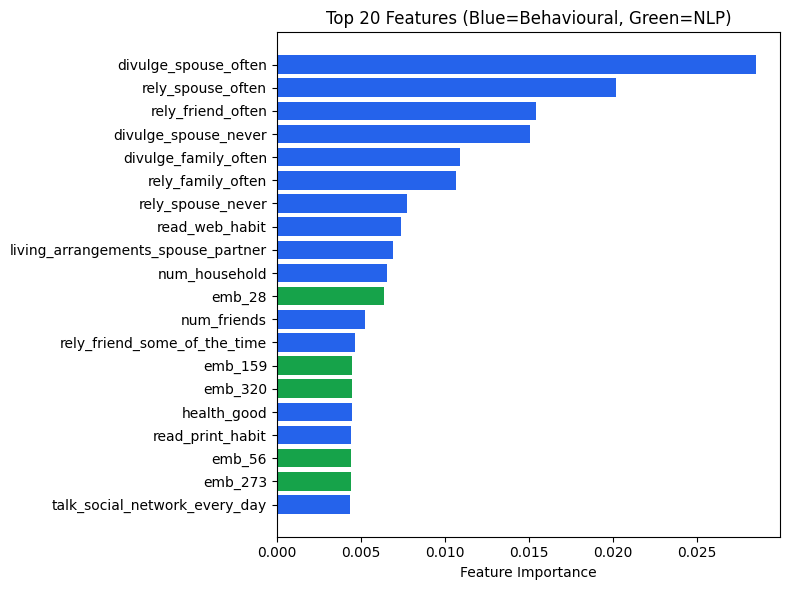

In [12]:
behav_cols = [c for c in X_combined.columns if not c.startswith('emb_')]
nlp_cols = [c for c in X_combined.columns if c.startswith('emb_')]

feature_importance = pd.DataFrame({
    'feature': X_train_val_res.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

# Aggregate: total importance from behavioural vs NLP features
behav_imp = feature_importance[~feature_importance['feature'].str.startswith('emb_')]['importance'].sum()
nlp_imp = feature_importance[feature_importance['feature'].str.startswith('emb_')]['importance'].sum()

print(f"Total importance — Behavioural: {behav_imp:.4f}, NLP: {nlp_imp:.4f}")
print(f"\nTop 15 features overall:")
print(feature_importance.head(15).to_string(index=False))

# Plot top 20
top20 = feature_importance.head(20)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2563eb' if not f.startswith('emb_') else '#16a34a' for f in top20['feature']]
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Features (Blue=Behavioural, Green=NLP)')
plt.tight_layout()
plt.show()

## 5. Export Model for App Integration

In [13]:
# Save the trained model, scaler, and feature columns so the demo app can load and use it

export_dir = os.path.join('..', 'artifacts')
os.makedirs(export_dir, exist_ok=True)

# Save the trained model and scaler
joblib.dump(final_model, os.path.join(export_dir, 'combined_rf_model.joblib'))
joblib.dump(scaler, os.path.join(export_dir, 'scaler.joblib'))

# Save the feature column order (needed for inference)
feature_cols = list(X_combined.columns)
joblib.dump(feature_cols, os.path.join(export_dir, 'feature_columns.joblib'))

# Save the sentence transformer model name for inference
with open(os.path.join(export_dir, 'model_config.txt'), 'w') as f:
    f.write(f"sentence_transformer={model_name}\n")
    f.write(f"n_behavioural_features={len(behav_cols)}\n")
    f.write(f"n_nlp_features={len(nlp_cols)}\n")
    f.write(f"label_map=1:low,2:moderate,3:high\n")

print(f"Model and artifacts saved to {export_dir}/")
print(f"Files: {os.listdir(export_dir)}")

Model and artifacts saved to ../artifacts/
Files: ['feature_columns.joblib', 'model_config.txt', 'scaler.joblib', 'combined_rf_model.joblib']
